# Algorithm 4

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt # pylint: disable=unused-import
import alg4
import covariance_matrices

rng = np.random.default_rng(seed=77)

## Test Scenarios

In [ ]:
N_TRIAL = 100 # number of observations N
ASPECT_RATIO = 0.9 # aspect ratio (d/N)
D_TRIAL = int(ASPECT_RATIO * N_TRIAL) # number of parameters D
MIN_D_N_TRIAL = min(N_TRIAL, D_TRIAL) # number of sigmas

Sigma_bulk = covariance_matrices.bulk(D_TRIAL) # bulk covariance
Sigma_spiked = covariance_matrices.spiked(D_TRIAL) # spiked covariance

M_THETA = 100 # number of random theta's
M_X = 50 # numbers of random X's
M_Y = 50 # numbers of random y's
EPSILON = 6.76767

In [ ]:
results_epsilon_1_bulk_lambda, results_epsilon_1_bulk_mse = alg4.EvaluateFixedX(N_TRIAL,
    D_TRIAL, Sigma_bulk, 1, M_THETA, M_X, M_Y)
results_epsilon_1_spiked_lambda, results_epsilon_1_spiked_mse = alg4.EvaluateFixedX(N_TRIAL,
    D_TRIAL, Sigma_spiked, 1, M_THETA, M_X, M_Y)

In [ ]:
with open('Data/results_epsilon_1_bulk_lambda.pkl', 'wb') as f:
    pickle.dump(results_epsilon_1_bulk_lambda, f)
with open('Data/results_epsilon_1_bulk_mse.pkl', 'wb') as f:
    pickle.dump(results_epsilon_1_bulk_mse, f)
with open('Data/results_epsilon_1_spiked_lambda.pkl', 'wb') as f:
    pickle.dump(results_epsilon_1_spiked_lambda, f)
with open('Data/results_epsilon_1_spiked_mse.pkl', 'wb') as f:
    pickle.dump(results_epsilon_1_spiked_mse, f)

In [ ]:
results_epsilon_67_bulk_lambda, results_epsilon_67_bulk_mse = alg4.EvaluateFixedX(
        N_TRIAL, D_TRIAL, Sigma_bulk, EPSILON, M_THETA, M_X, M_Y)
results_epsilon_67_spiked_lambda, results_epsilon_67_spiked_mse = alg4.EvaluateFixedX(
        N_TRIAL, D_TRIAL, Sigma_spiked, EPSILON, M_THETA, M_X, M_Y)

In [ ]:
with open('Data/results_epsilon_67_bulk_lambda.pkl', 'wb') as f:
    pickle.dump(results_epsilon_67_bulk_lambda, f)
with open('Data/results_epsilon_67_bulk_mse.pkl', 'wb') as f:
    pickle.dump(results_epsilon_67_bulk_mse, f)
with open('Data/results_epsilon_67_spiked_lambda.pkl', 'wb') as f:
    pickle.dump(results_epsilon_67_spiked_lambda, f)
with open('Data/results_epsilon_67_spiked_mse.pkl', 'wb') as f:
    pickle.dump(results_epsilon_67_spiked_mse, f)

In [ ]:
results_epsilon_67_bulk_lambda, results_epsilon_small_bulk_mse = alg4.EvaluateFixedX(
        N_TRIAL, D_TRIAL, Sigma_bulk, 0.0001, M_THETA, M_X, M_Y)
results_epsilon_67_spiked_lambda, results_epsilon_small_spiked_mse = alg4.EvaluateFixedX(
        N_TRIAL, D_TRIAL, Sigma_spiked, EPSILON, M_THETA, M_X, M_Y)

## Analysis

### Data

In [2]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

In [3]:
results_epsilon_1_bulk_lambda = load_pickle('Data/results_epsilon_1_bulk_lambda.pkl')
results_epsilon_1_bulk_mse = load_pickle('Data/results_epsilon_1_bulk_mse.pkl')
results_epsilon_1_spiked_lambda = load_pickle('Data/results_epsilon_1_spiked_lambda.pkl')
results_epsilon_1_spiked_mse = load_pickle('Data/results_epsilon_1_spiked_mse.pkl')

In [4]:
results_epsilon_67_bulk_lambda = load_pickle('Data/results_epsilon_67_bulk_lambda.pkl')
results_epsilon_67_bulk_mse = load_pickle('Data/results_epsilon_67_bulk_mse.pkl')
results_epsilon_67_spiked_lambda = load_pickle('Data/results_epsilon_67_spiked_lambda.pkl')
results_epsilon_67_spiked_mse = load_pickle('Data/results_epsilon_67_spiked_mse.pkl')

### Results

In [ ]:
def plot_lambda_distributions(lambda_results, title):
    method_names = (
        "Global minimum",
        "Fixed point",
        "Sample fixed point",
        "Signal-to-noise",
    )
    expected_ndim = (2, 2, 3, 3)

    figure, axis = plt.subplots(figsize=(10, 6), constrained_layout=True)
    samples_list = [values.ravel() for values in lambda_results]

    axis.boxplot(
        samples_list,
        orientation='vertical',
        patch_artist=True,
        boxprops={"facecolor": "steelblue"},
        medianprops={"color": "black", "linewidth": 2},
        flierprops={"marker": ".", "markersize": 1, "alpha": 0.25},
    )
    axis.set_xticks(range(1, len(method_names) + 1))
    axis.set_xticklabels(method_names)
    axis.set_ylabel("lambda")
    axis.grid(axis="y", alpha=0.25)

    figure.suptitle(title, fontsize=14)
    plt.show()
    return figure, axes

In [ ]:
def plot_mse_distributions(mse_results, title):
    method_names = (
        "Global minimum",
        "Fixed point",
        "Sample fixed point",
        "Signal-to-noise",
        "Default regularization",
    )
    expected_ndim = (2, 2, 3, 3, 2)

    figure, axis = plt.subplots(figsize=(10, 6), constrained_layout=True)
    samples_list = [values.ravel() for values in mse_results]

    axis.boxplot(
        samples_list,
        orientation='vertical',
        patch_artist=True,
        boxprops={"facecolor": "steelblue"},
        medianprops={"color": "black", "linewidth": 1},
        flierprops={"marker": ".", "markersize": 2, "alpha": 0.25},
    )
    axis.set_xticks(range(1, len(method_names) + 1))
    axis.set_xticklabels(method_names)
    axis.set_ylabel("MSE")
    axis.grid(axis="y", alpha=0.25)

    figure.suptitle(title, fontsize=14)
    plt.show()
    return figure, axes

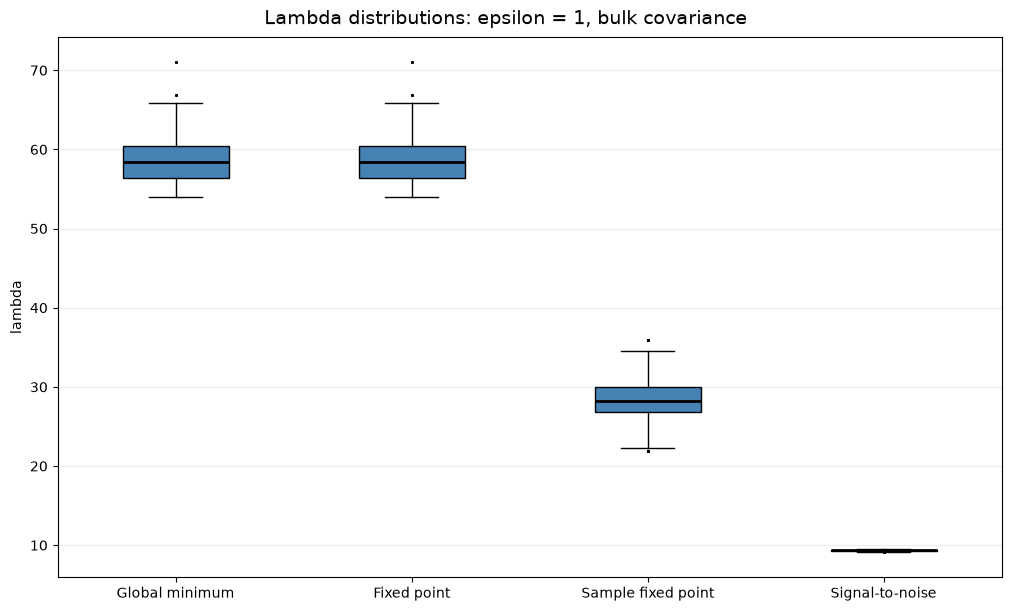

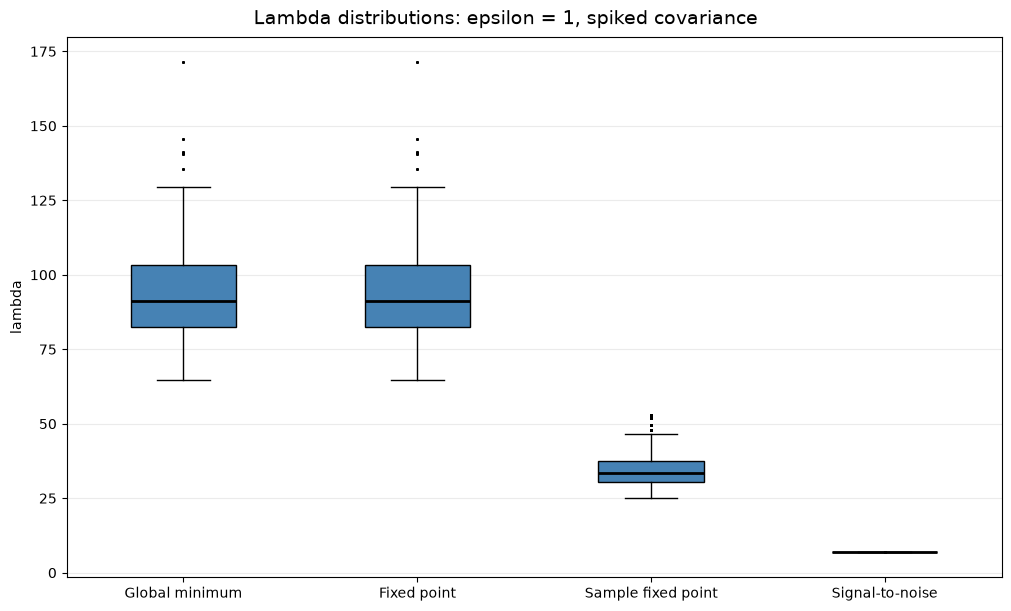

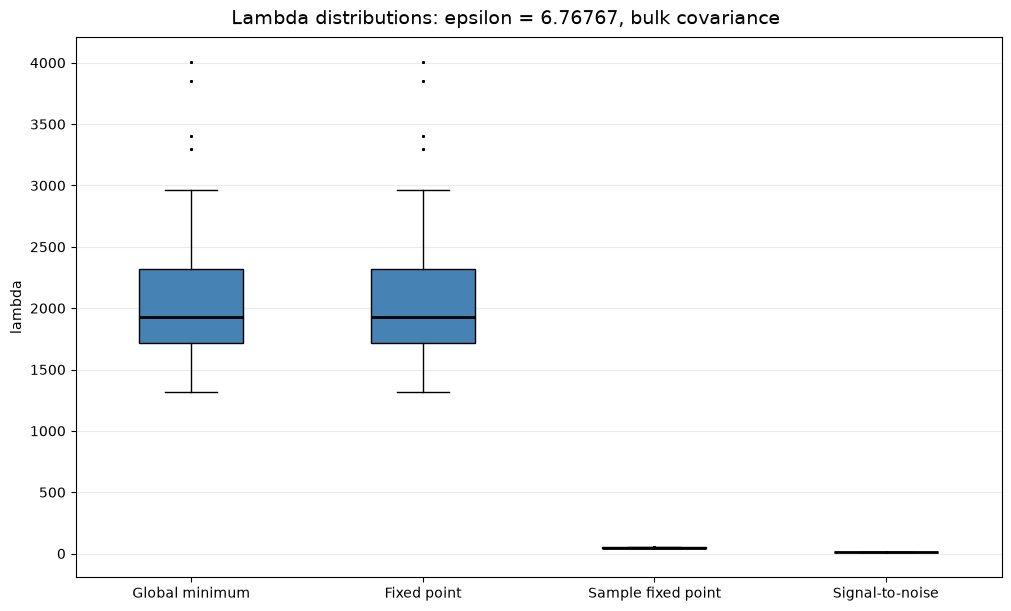

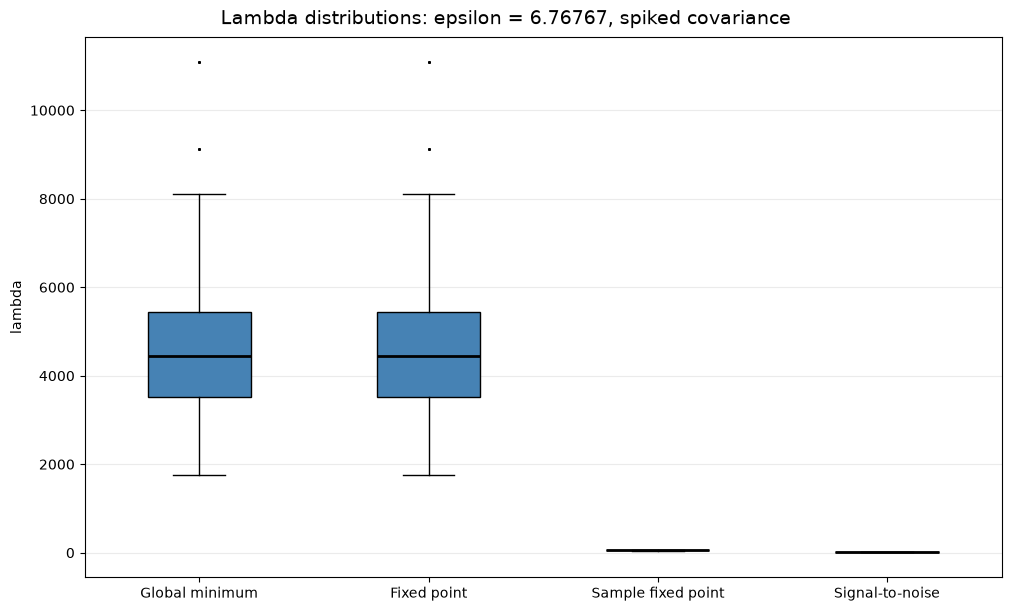

In [ ]:
figure, axes = plot_lambda_distributions(
    results_epsilon_1_bulk_lambda,
    "Lambda distributions: epsilon = 1, bulk covariance",
)

figure, axes = plot_lambda_distributions(
    results_epsilon_1_spiked_lambda,
    "Lambda distributions: epsilon = 1, spiked covariance",
)

figure, axes = plot_lambda_distributions(
    results_epsilon_67_bulk_lambda,
    "Lambda distributions: epsilon = 6.76767, bulk covariance",
)

figure, axes = plot_lambda_distributions(
    results_epsilon_67_spiked_lambda,
    "Lambda distributions: epsilon = 6.76767, spiked covariance",
)

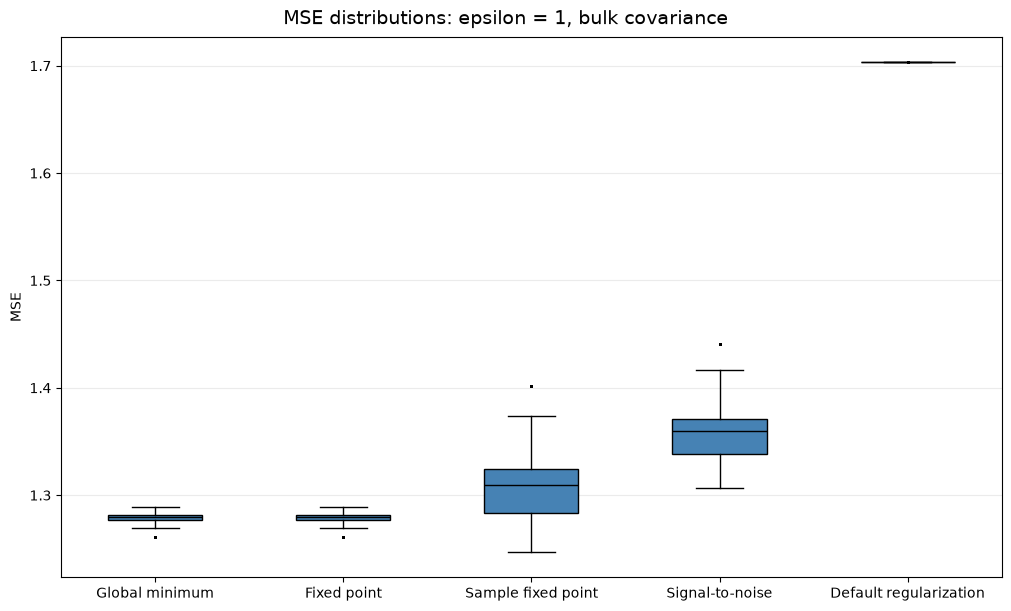

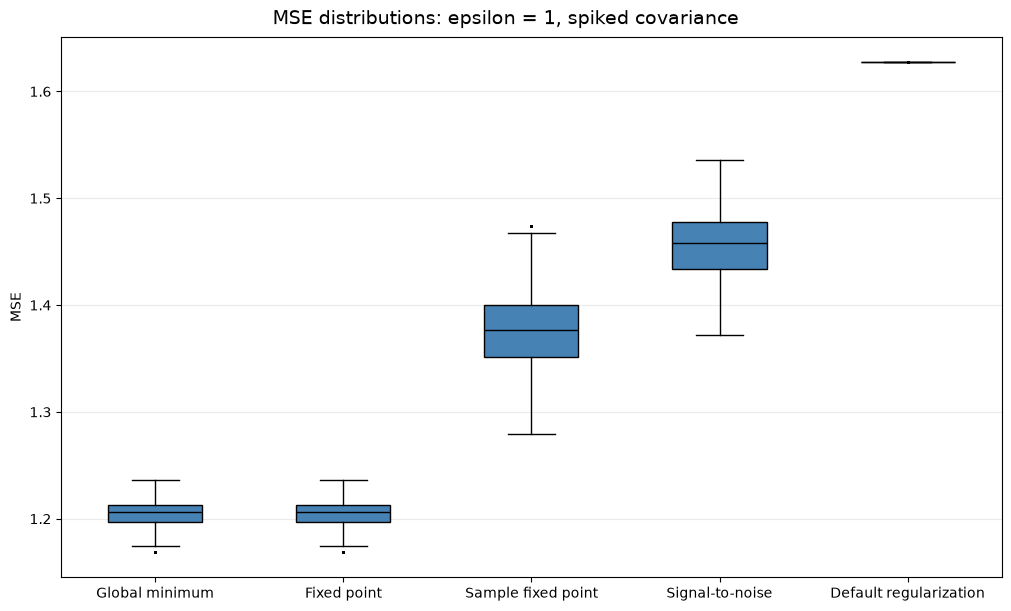

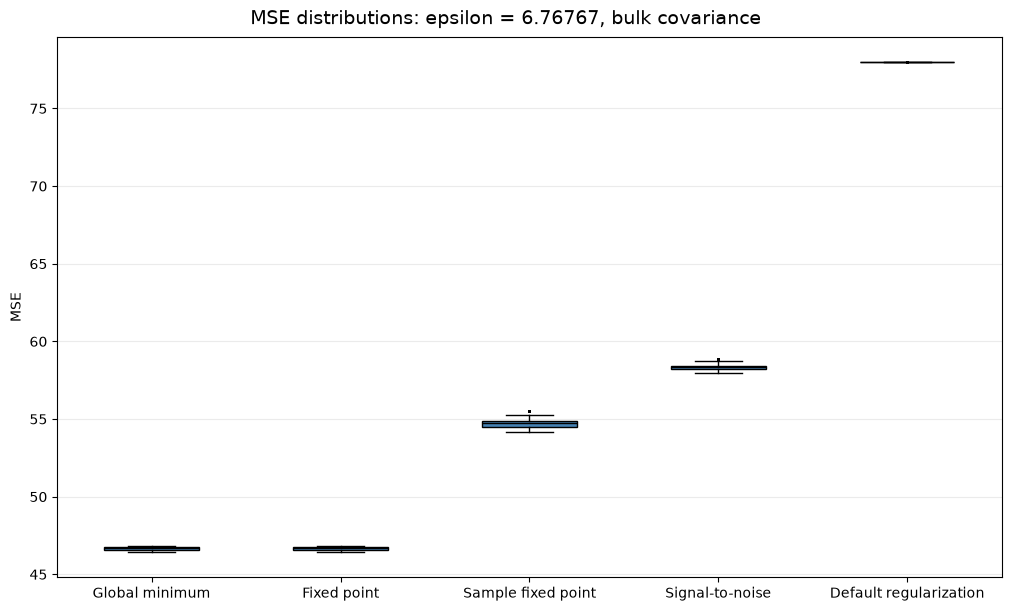

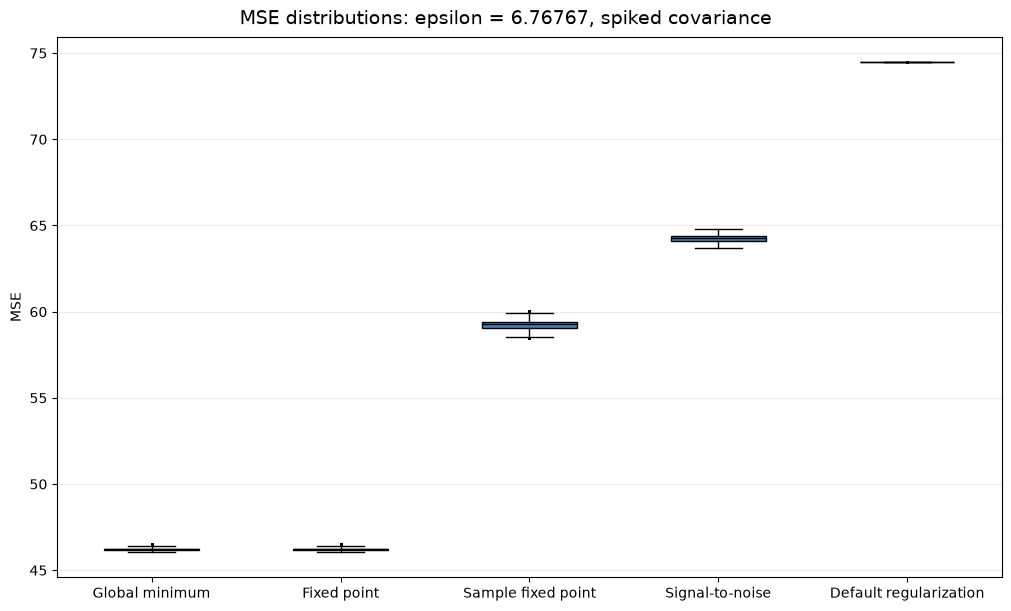

In [48]:
figure, axes = plot_mse_distributions(
    results_epsilon_1_bulk_mse,
    "MSE distributions: epsilon = 1, bulk covariance",
)

figure, axes = plot_mse_distributions(
    results_epsilon_1_spiked_mse,
    "MSE distributions: epsilon = 1, spiked covariance",
)

figure, axes = plot_mse_distributions(
    results_epsilon_67_bulk_mse,
    "MSE distributions: epsilon = 6.76767, bulk covariance",
)

figure, axes = plot_mse_distributions(
    results_epsilon_67_spiked_mse,
    "MSE distributions: epsilon = 6.76767, spiked covariance",
)